In [1]:
import pandas as pd
import numpy as np
from utils.mpip_parse import MPIPParser
from utils.parse_coscheduling_runs import CoSchedulingRunsParser
import matplotlib.pyplot as plt
from utils.parse_rate_limits import RateLimitParser

In [2]:
parser = CoSchedulingRunsParser()
data_isolated = parser.parse_isolated("../run_data/experiments_coscheduling_isolated/20260527_083005/data", progress=True)
data_coscheduled = parser.parse_coscheduled("../run_data/experiments_coscheduling_app_coscheduled/20260527_082956/data", progress=True)

Phase 1: Collecting files: 64it [00:00, 24584.25it/s]
Phase 2: Parsing files: 100%|██████████| 64/64 [00:07<00:00,  8.17it/s]
Phase 1: Collecting files: 304it [00:00, 59660.70it/s]
Phase 2: Parsing files: 100%|██████████| 304/304 [01:25<00:00,  3.55it/s]


In [5]:
# Aggregate data_isolated by App and Num Nodes
# Group by App and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_isolated_agg = data_isolated.groupby(['App', 'Num Nodes']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std'],
    'Total Bytes Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_isolated_agg.columns = ['App', 'Num Nodes', 
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std',
                             'Total Bytes Sent Mean', 'Total Bytes Sent Median', 'Total Bytes Sent Std']

data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]

# Aggregate data_coscheduled by App A, App B, and Num Nodes
# Group by App A, App B, and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_coscheduled_agg = data_coscheduled.groupby(['App A', 'App B', 'Num Nodes']).agg({
    'App A Time Average': ['mean', 'median', 'std'],
    'App B Time Average': ['mean', 'median', 'std'],
    'App A MPI Time Average': ['mean', 'median', 'std'],
    'App B MPI Time Average': ['mean', 'median', 'std'],
    'App A Total Messages Sent': ['mean', 'median', 'std'],
    'App B Total Messages Sent': ['mean', 'median', 'std'],
    'App A Total Bytes Sent': ['mean', 'median', 'std'],
    'App B Total Bytes Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_coscheduled_agg.columns = ['App A', 'App B', 'Num Nodes',
                                'App A Time Average Mean', 'App A Time Average Median', 'App A Time Average Std',
                                'App B Time Average Mean', 'App B Time Average Median', 'App B Time Average Std',
                                'App A MPI Time Average Mean', 'App A MPI Time Average Median', 'App A MPI Time Average Std',
                                'App B MPI Time Average Mean', 'App B MPI Time Average Median', 'App B MPI Time Average Std',
                                'App A Total Messages Sent Mean', 'App A Total Messages Sent Median', 'App A Total Messages Sent Std',
                                'App B Total Messages Sent Mean', 'App B Total Messages Sent Median', 'App B Total Messages Sent Std',
                                'App A Total Bytes Sent Mean', 'App A Total Bytes Sent Median', 'App A Total Bytes Sent Std',
                                'App B Total Bytes Sent Mean', 'App B Total Bytes Sent Median', 'App B Total Bytes Sent Std']

In [6]:
rate_limit_parser = RateLimitParser("../rate_limit_data/20260625_114931/data")
rate_limit_parser.parse()
rate_limits = rate_limit_parser.get_rate_limits()
bandwidths = rate_limit_parser.get_bandwidths()

In [7]:
rate_limits

,Rank A,Rank B,Rate Limit (messages/sec),Run Index
0,0,1,7651560.0,0
1,0,2,5711840.0,0
2,0,3,5673710.0,0
3,0,4,6669250.0,0
4,0,5,6617080.0,0
...,...,...,...,...
555,7,2,3923370.0,9
556,7,3,3922580.0,9
557,7,4,5017810.0,9
558,7,5,3981720.0,9


In [8]:
bandwidths

,Rank A,Rank B,Bandwidth (MB/s),Run Index
0,0,1,24811.26,0
1,0,2,22670.20,0
2,0,3,22474.78,0
3,0,4,14070.80,0
4,0,5,14171.33,0
...,...,...,...,...
555,7,2,10297.39,9
556,7,3,9966.91,9
557,7,4,22344.90,9
558,7,5,22406.57,9


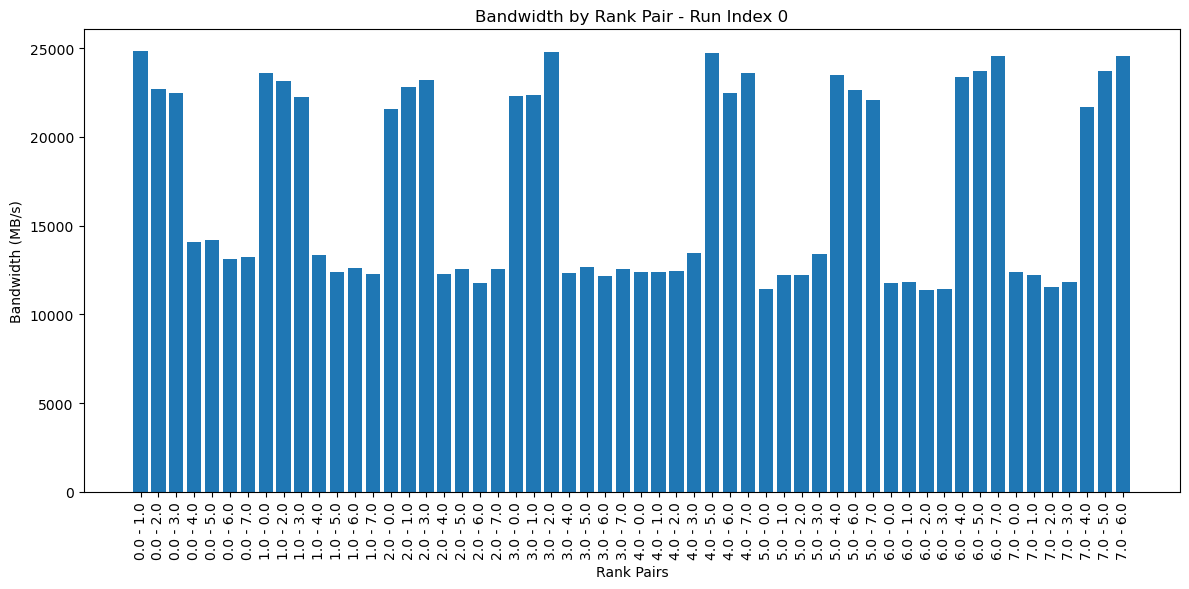

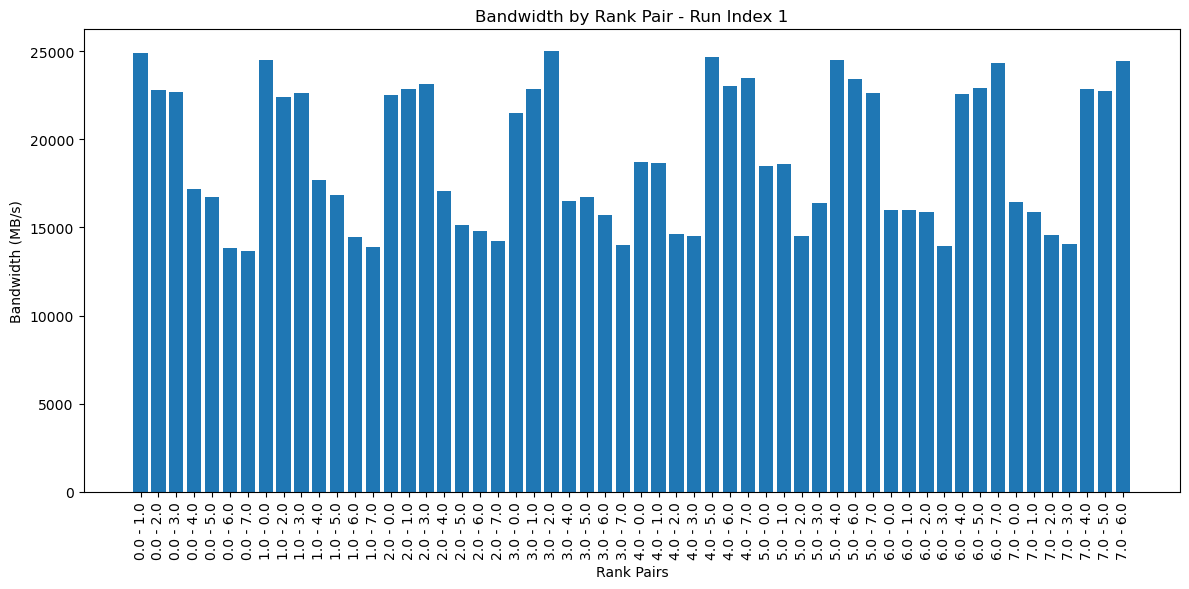

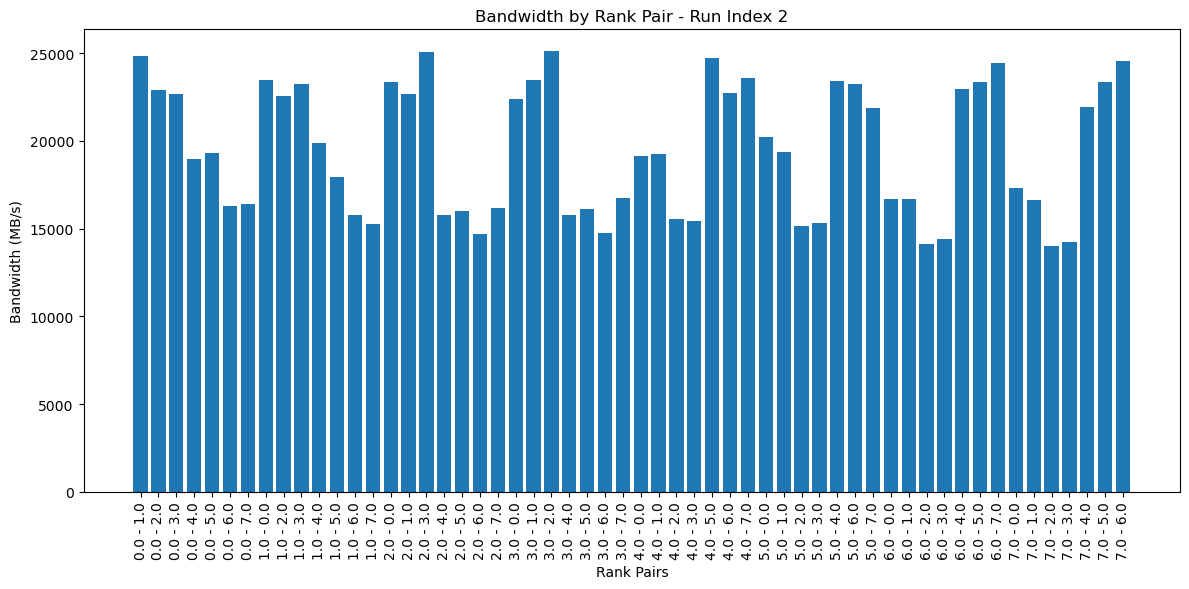

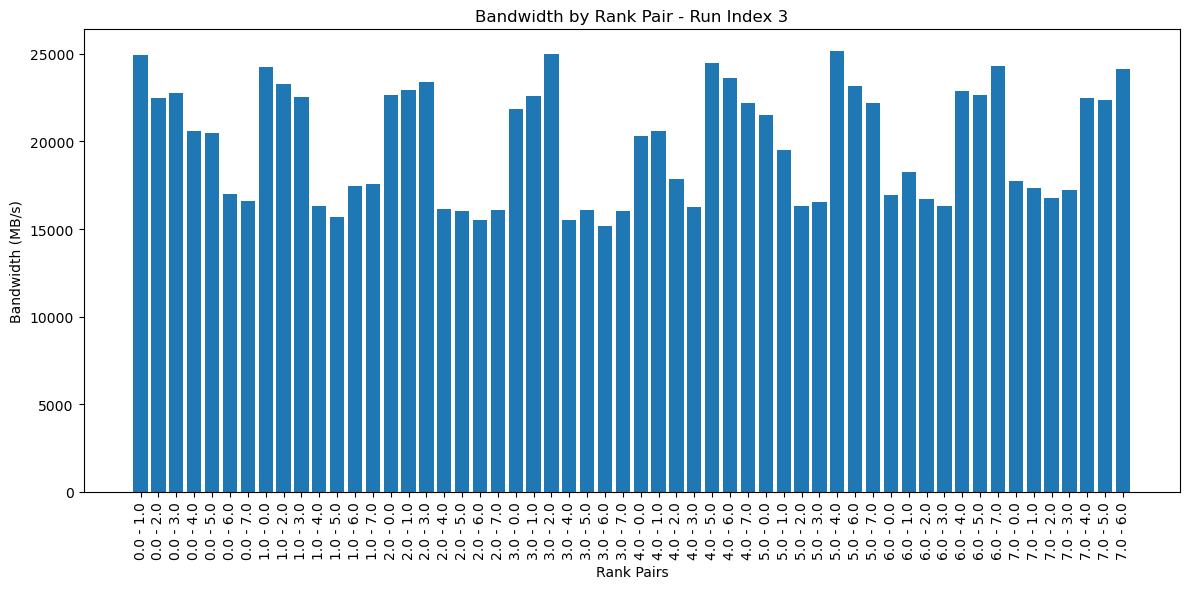

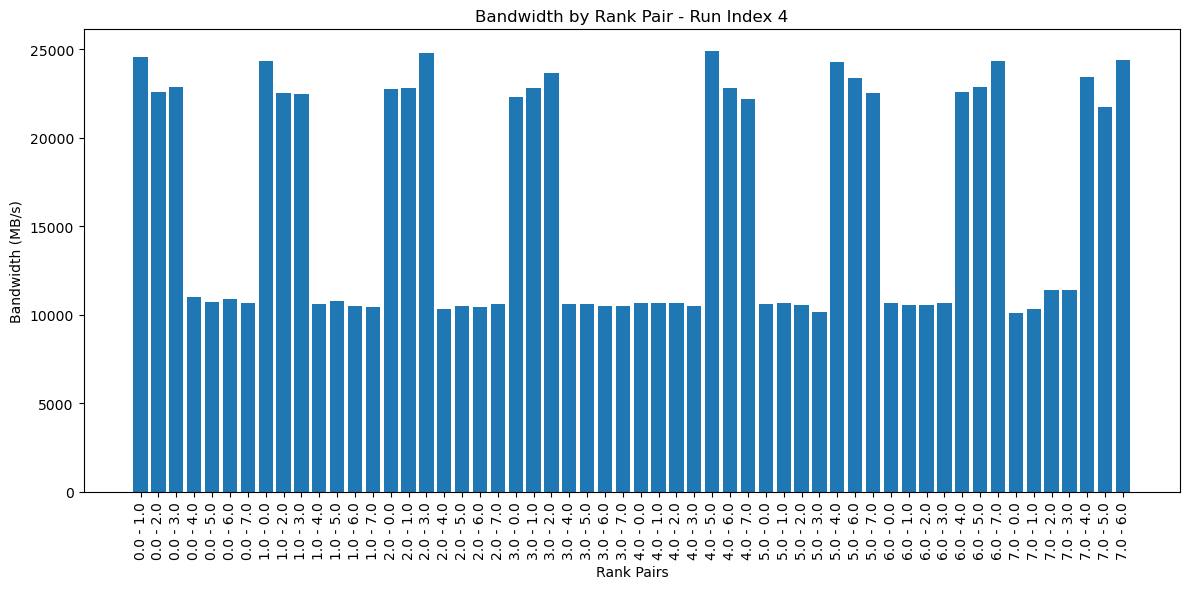

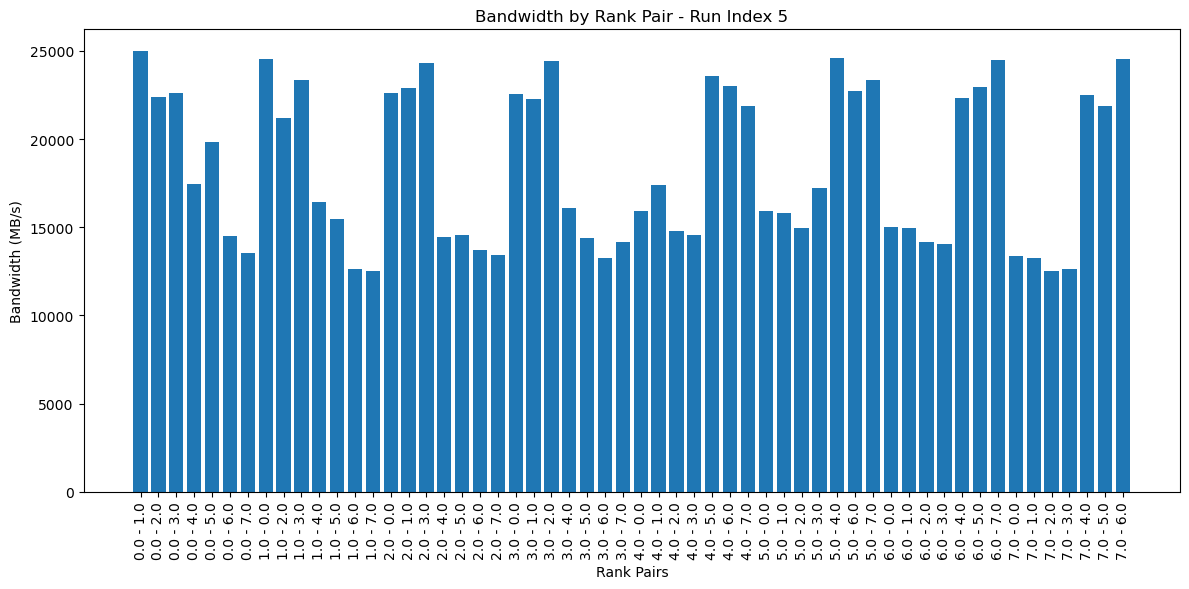

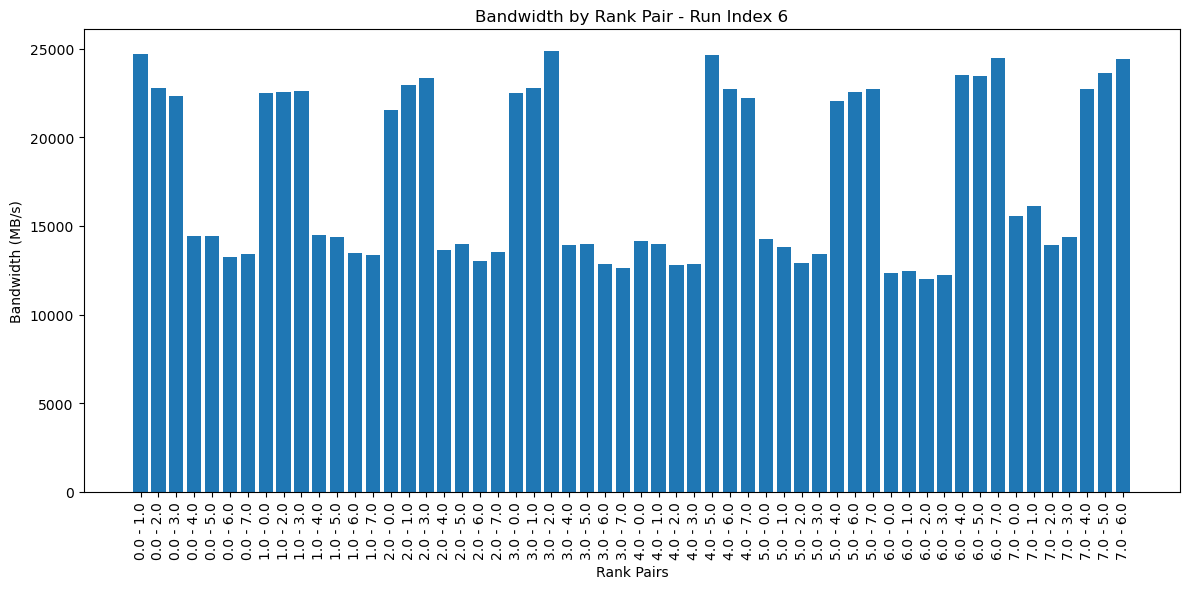

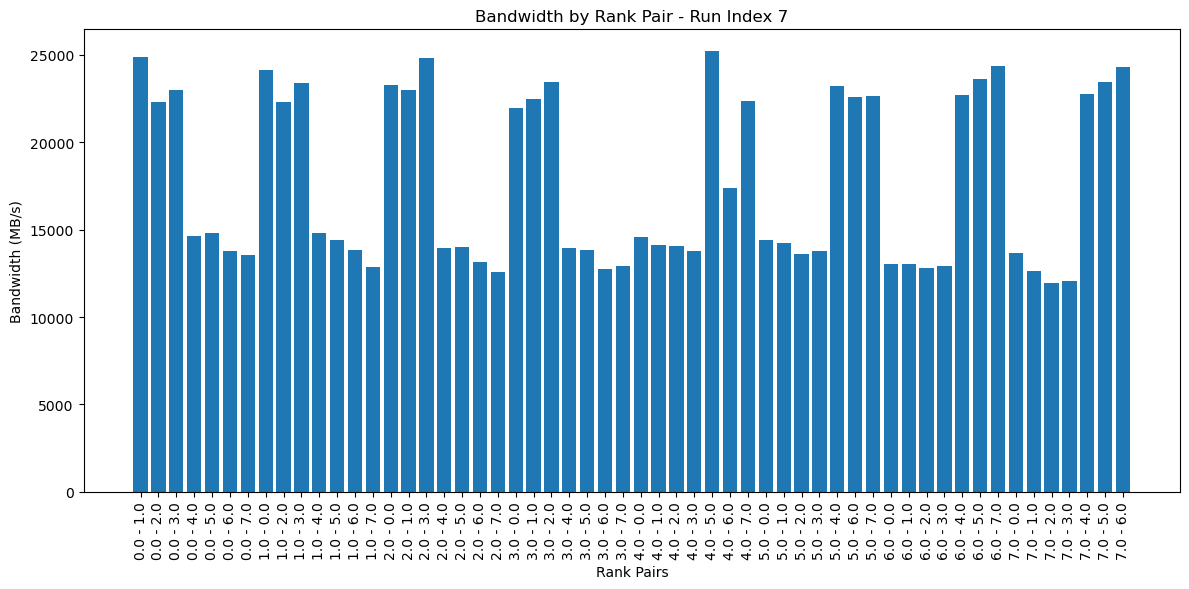

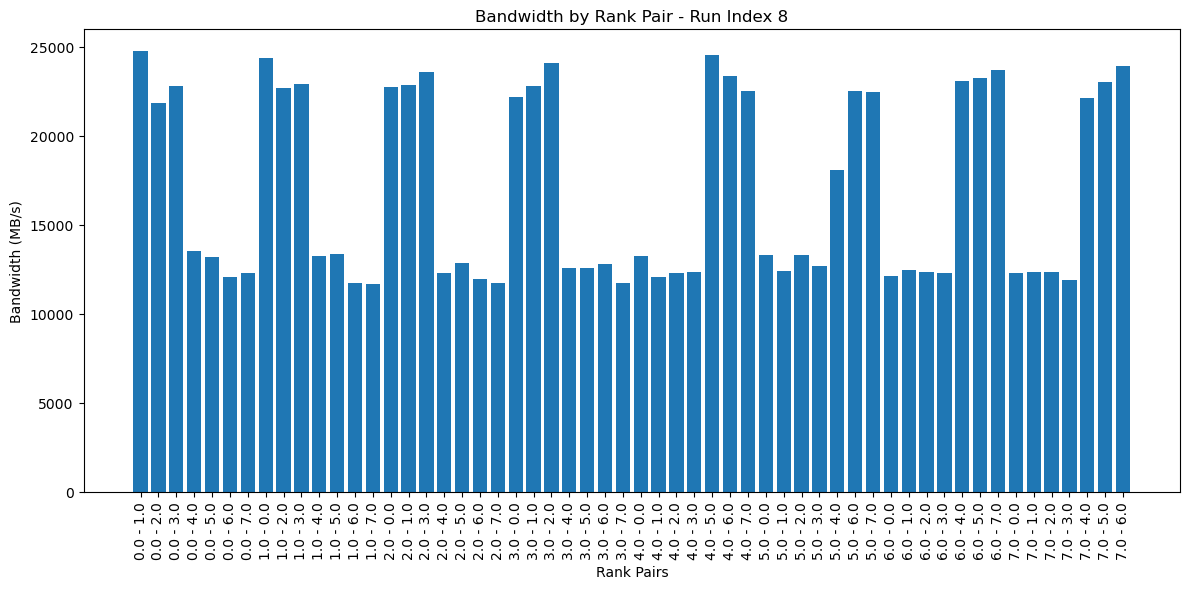

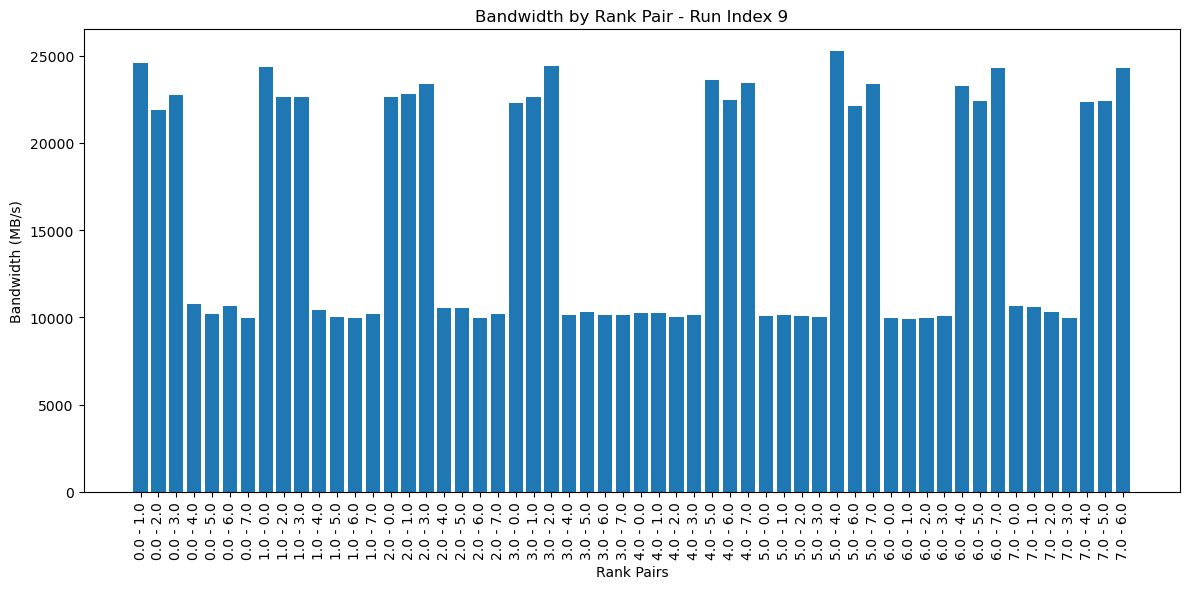

In [9]:
for run_index in bandwidths['Run Index'].unique():
    df_run = bandwidths[bandwidths['Run Index'] == run_index]
    
    plt.figure(figsize=(12, 6))
    x_labels = [f"{row['Rank A']} - {row['Rank B']}" for _, row in df_run.iterrows()]
    y_values = df_run['Bandwidth (MB/s)'].values
    
    plt.bar(range(len(x_labels)), y_values)
    plt.xticks(range(len(x_labels)), x_labels, rotation=90)
    plt.xlabel("Rank Pairs")
    plt.ylabel("Bandwidth (MB/s)")
    plt.title(f"Bandwidth by Rank Pair - Run Index {run_index}")
    plt.tight_layout()
    plt.show()

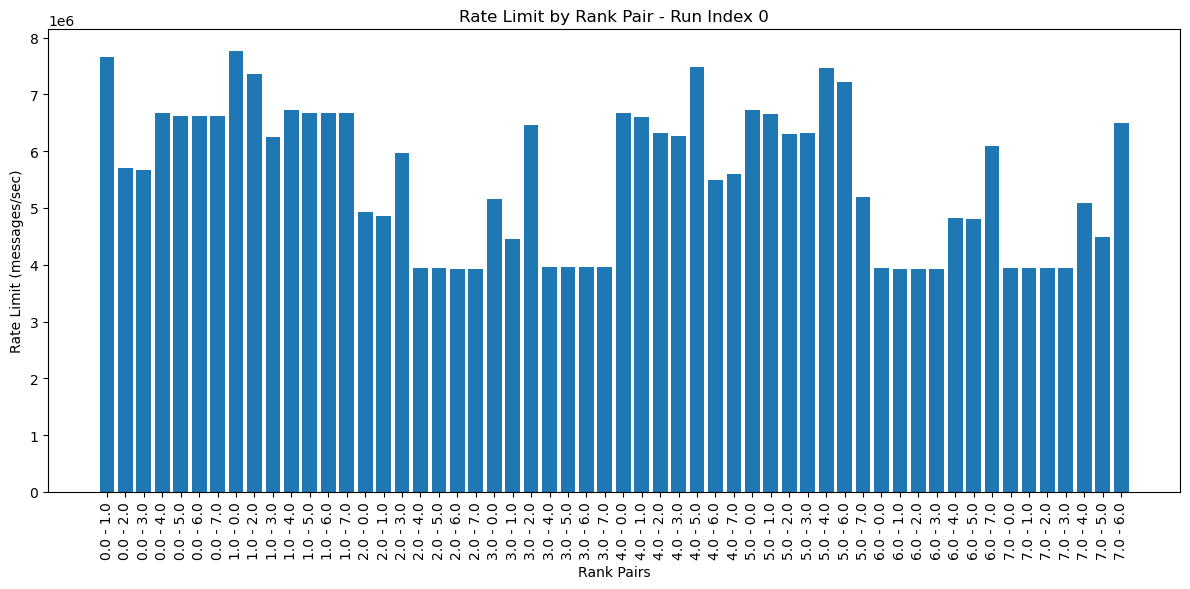

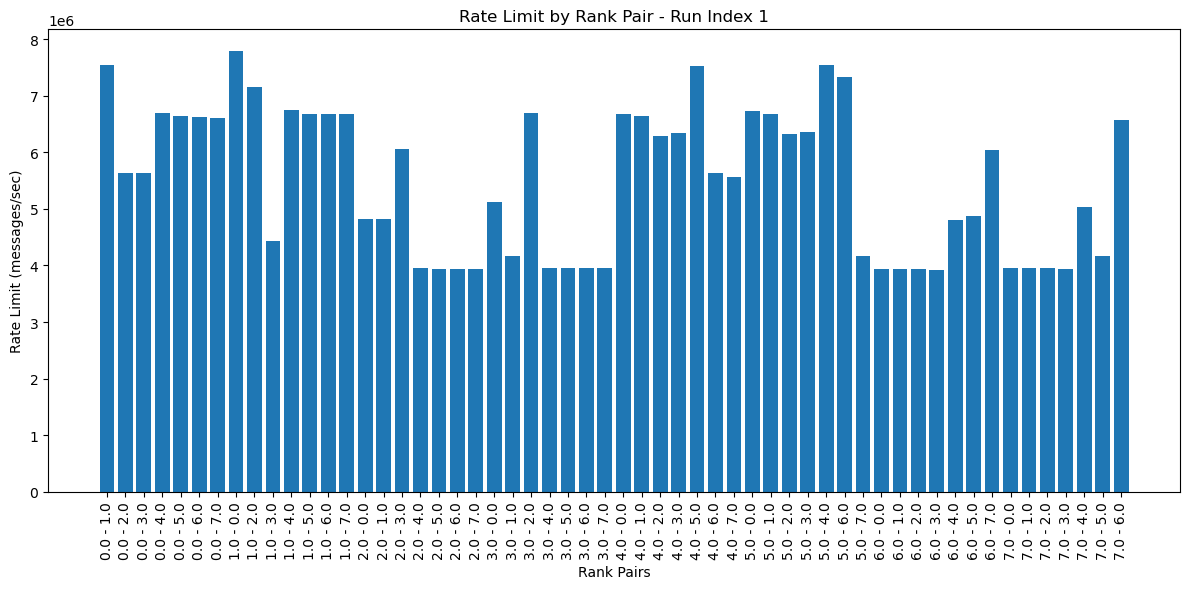

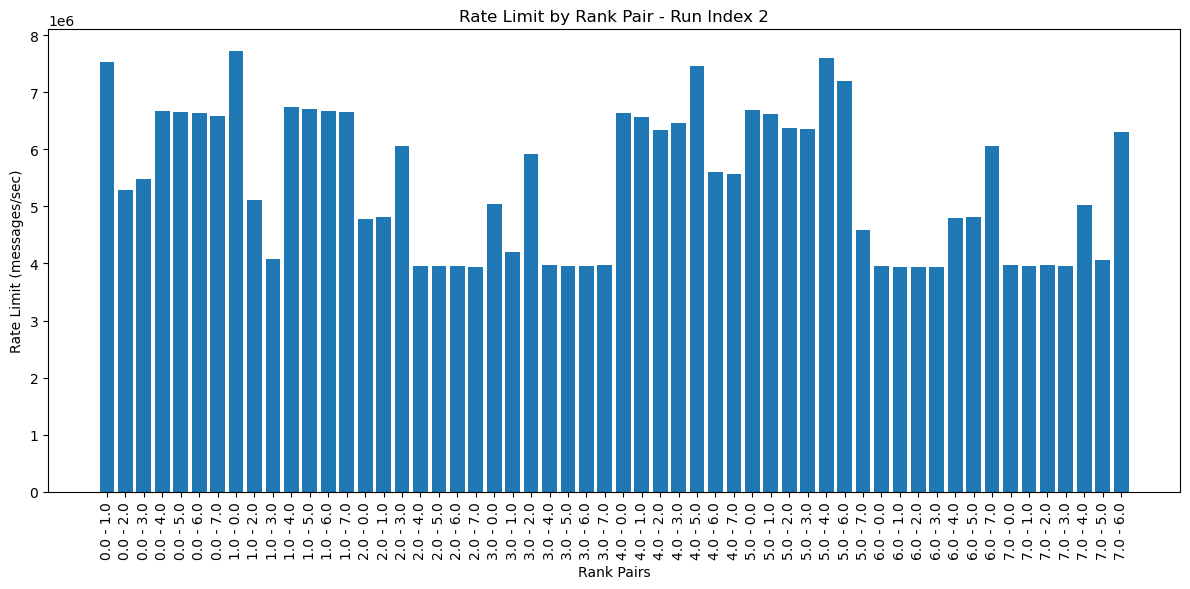

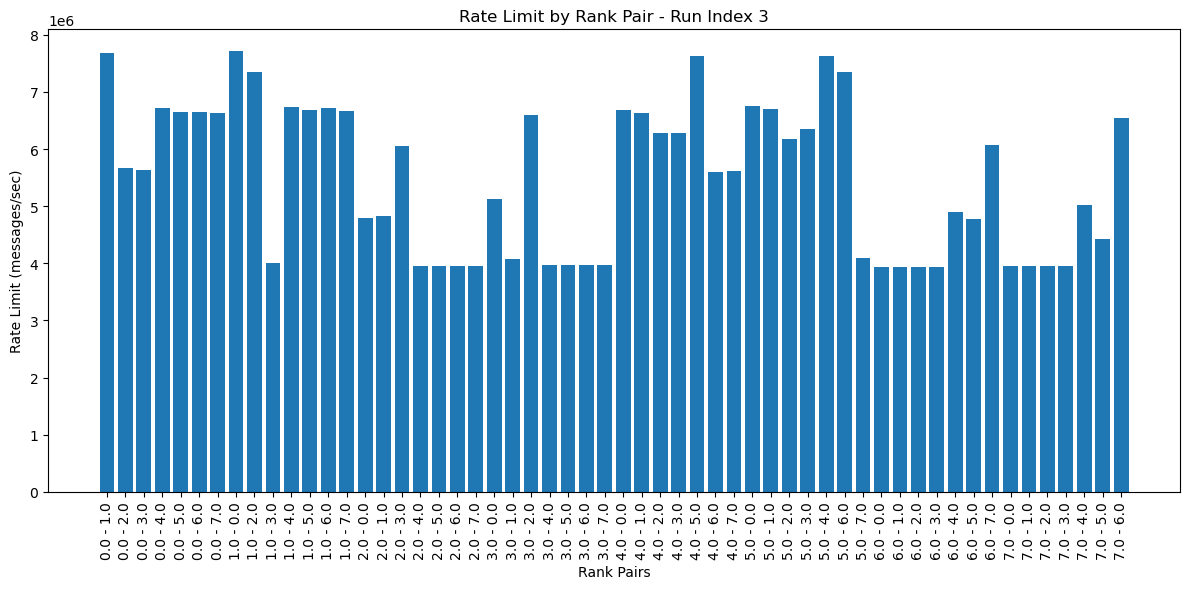

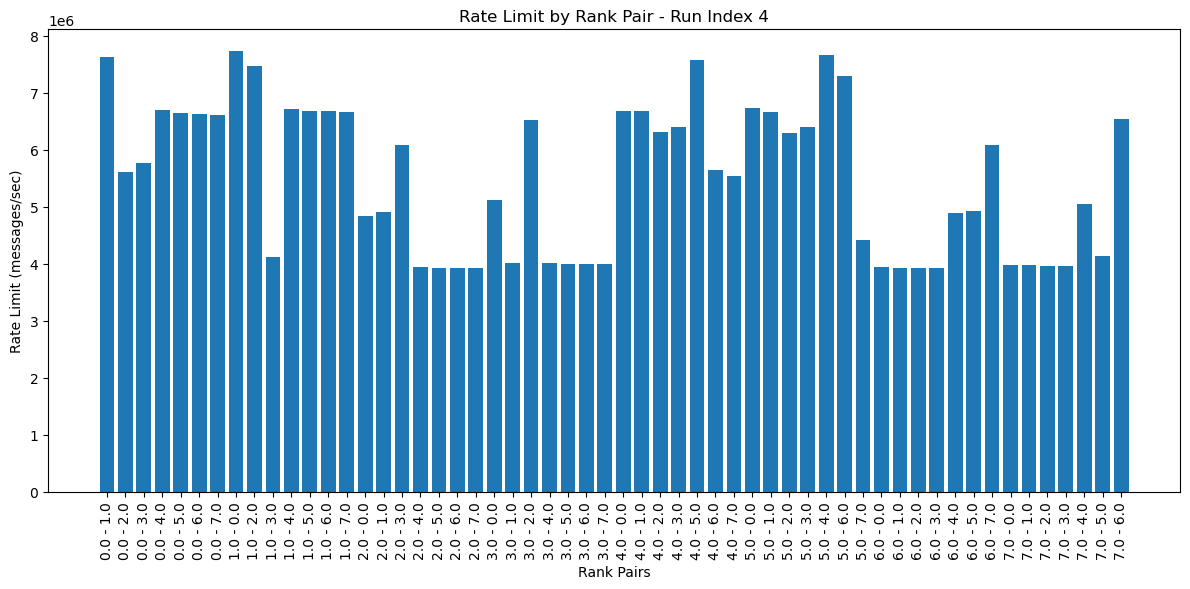

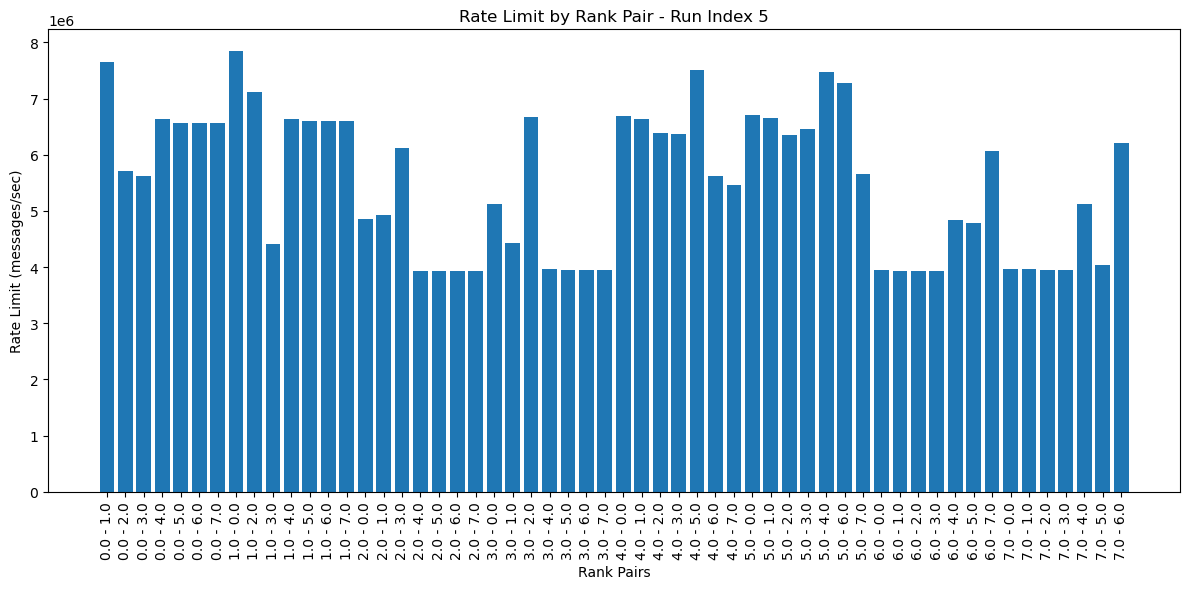

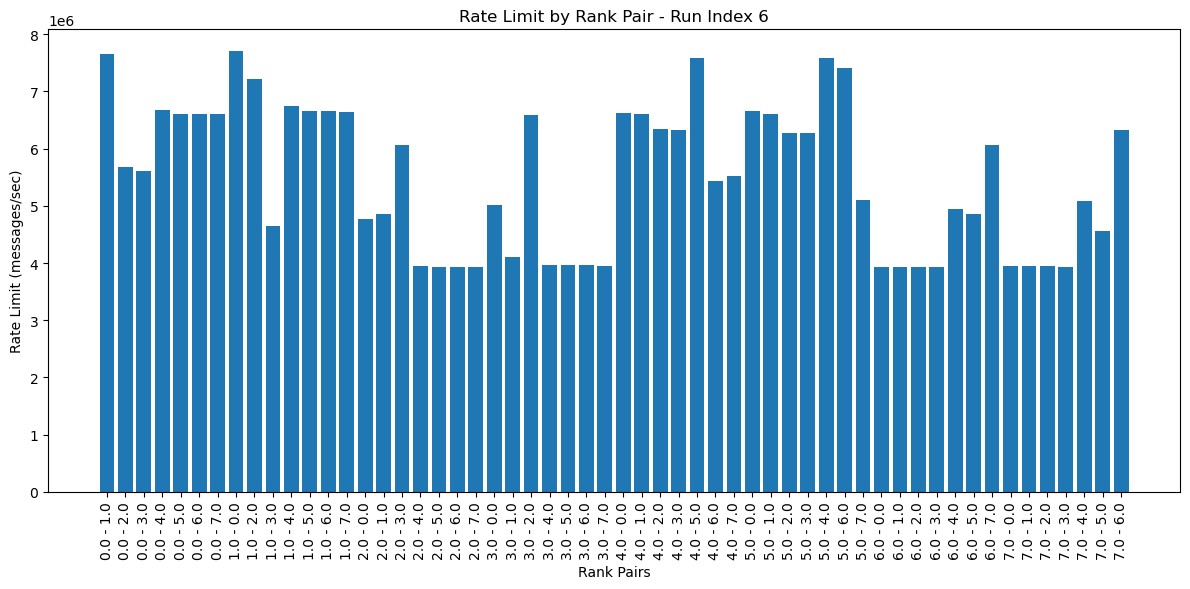

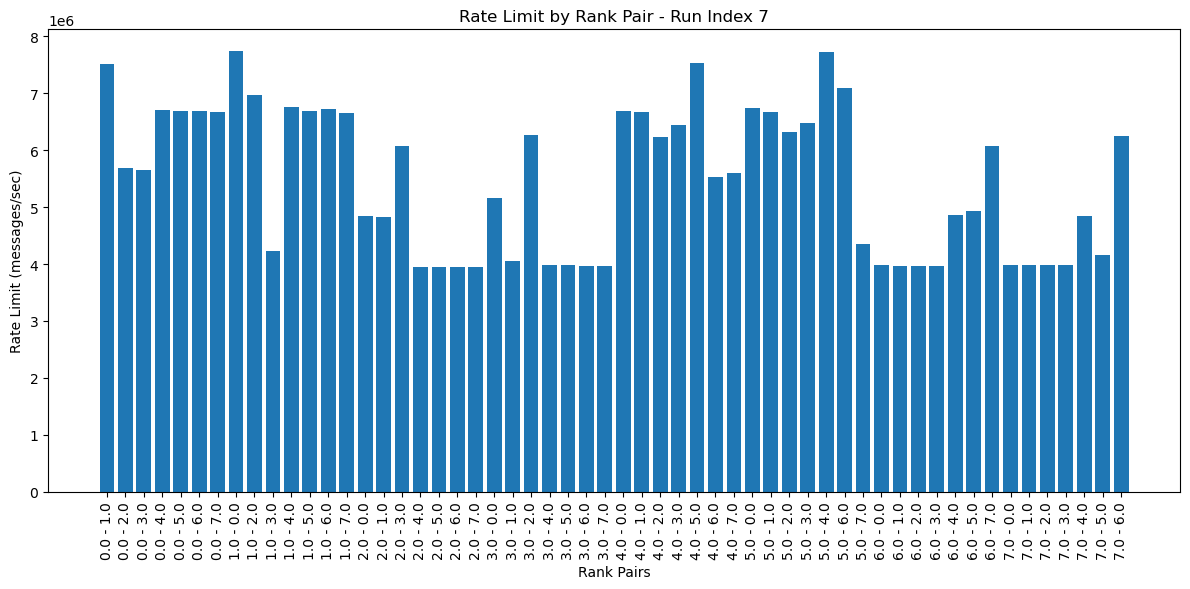

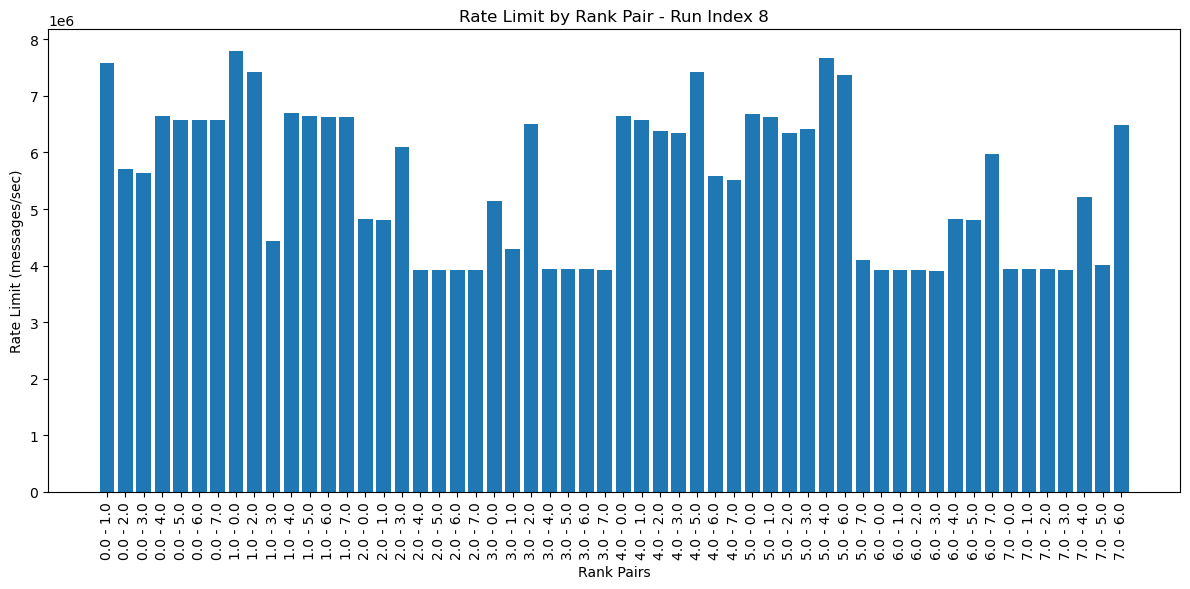

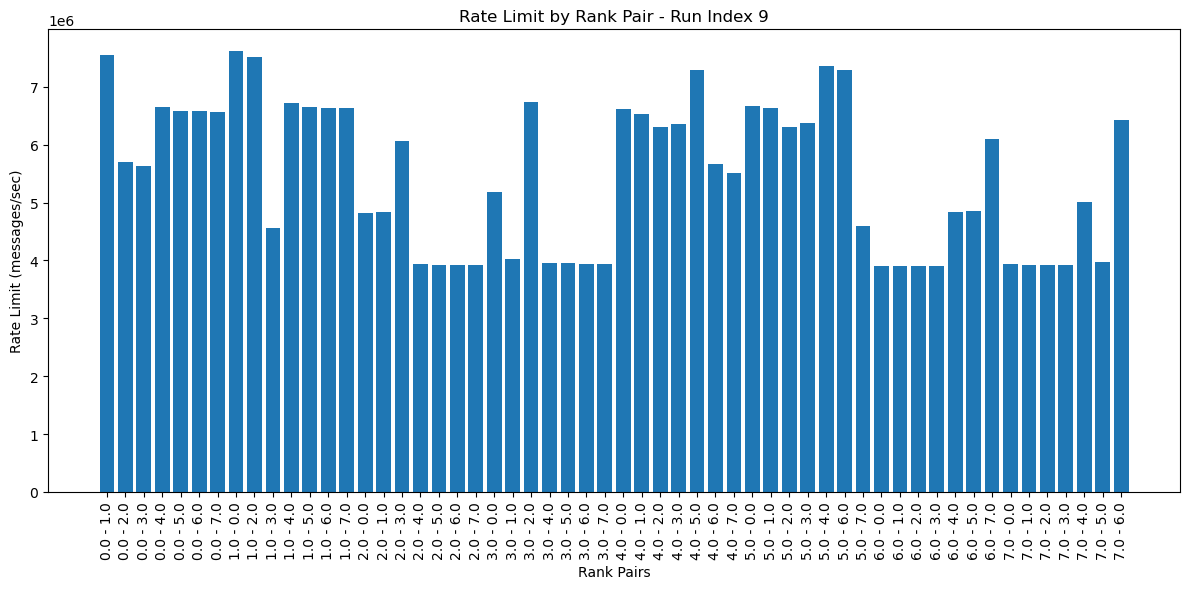

In [10]:
for run_index in rate_limits['Run Index'].unique():
    df_run = rate_limits[rate_limits['Run Index'] == run_index]
    
    plt.figure(figsize=(12, 6))
    x_labels = [f"{row['Rank A']} - {row['Rank B']}" for _, row in df_run.iterrows()]
    y_values = df_run['Rate Limit (messages/sec)'].values
    
    plt.bar(range(len(x_labels)), y_values)
    plt.xticks(range(len(x_labels)), x_labels, rotation=90)
    plt.xlabel("Rank Pairs")
    plt.ylabel("Rate Limit (messages/sec)")
    plt.title(f"Rate Limit by Rank Pair - Run Index {run_index}")
    plt.tight_layout()
    plt.show()

In [11]:
data_isolated_agg[(data_isolated_agg["App"] == "beatnik") & (data_isolated_agg["Num Nodes"] == 8)]

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std,Total Bytes Sent Mean,Total Bytes Sent Median,Total Bytes Sent Std
2,beatnik,8,397.734375,396.977679,4.860808,99.906362,98.491295,3.282818,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0


In [12]:
data_coscheduled_agg[(data_coscheduled_agg["App A"] == "beatnik") & (data_coscheduled_agg["App B"] == "beatnik") & (data_coscheduled_agg["Num Nodes"] == 8)]

,App A,App B,Num Nodes,App A Time Average Mean,App A Time Average Median,App A Time Average Std,App B Time Average Mean,App B Time Average Median,App B Time Average Std,App A MPI Time Average Mean,...,App A Total Messages Sent Std,App B Total Messages Sent Mean,App B Total Messages Sent Median,App B Total Messages Sent Std,App A Total Bytes Sent Mean,App A Total Bytes Sent Median,App A Total Bytes Sent Std,App B Total Bytes Sent Mean,App B Total Bytes Sent Median,App B Total Bytes Sent Std
6,beatnik,beatnik,8,449.412388,450.0,18.7263,448.563616,449.127232,19.149793,158.868862,...,0.0,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0,0.0,0.0,0.0


In [13]:
# App profiles
app_profiles = {}
for app in data_isolated_agg["App"].unique():
    filtered_data_isolated_agg = data_isolated_agg[(data_isolated_agg["App"] == app) & (data_isolated_agg["Num Nodes"] == 8)]
    app_profiles[app] = {}
    app_profiles[app]["App Time"] = filtered_data_isolated_agg["App Time Average Mean"].mean()
    app_profiles[app]["MPI Time"] = filtered_data_isolated_agg["MPI Time Average Mean"].mean()
    app_profiles[app]["Total Bytes"] = filtered_data_isolated_agg["Total Bytes Sent Mean"].mean()
    app_profiles[app]["Total Messages"] = filtered_data_isolated_agg["Total Messages Sent Mean"].mean()
    app_profiles[app]["Message Rate"] = filtered_data_isolated_agg["Total Messages Sent Mean"].mean()/filtered_data_isolated_agg["App Time Average Mean"].mean()
    app_profiles[app]["Message Size Avg"] = filtered_data_isolated_agg["Total Bytes Sent Mean"].mean()/filtered_data_isolated_agg["Total Messages Sent Mean"].mean()

In [16]:
# System profiles
# C_bandwidth = bandwidths["Bandwidth (MB/s)"].median()
C_bandwidth = 184.346 * (10**9) # GB/s to B/s
# C_msg_rate = rate_limits["Rate Limit (messages/sec)"].median()
C_msg_rate = 87070136990993.09 
print(f"Bandwidth: {C_bandwidth} MB/s, Rate Limit: {C_msg_rate} messages/sec")

Bandwidth: 184346000000.0 MB/s, Rate Limit: 87070136990993.1 messages/sec


In [28]:
def predict_comm_slowdown(app_A, app_B):
    app_A_profiles = app_profiles[app_A]
    app_B_profiles = app_profiles[app_B]

    # --- Isolated rates ---
    R_bw_A = app_A_profiles["Total Bytes"] / app_A_profiles["MPI Time"]
    R_bw_B = app_B_profiles["Total Bytes"] / app_B_profiles["MPI Time"]
    R_bw_total = R_bw_A + R_bw_B

    # --- System service rate (mu) in bytes/sec ---
    avg_msg_size = (app_A_profiles["Total Bytes"] + app_B_profiles["Total Bytes"]) / \
                   (app_A_profiles["Total Messages"] + app_B_profiles["Total Messages"])
    
    # Ensure C_bandwidth is in Bytes/sec (if it's MB/s, multiply by 1e6 or 1024^2)
    mu_bytes = C_bandwidth          
    mu_msg_limit = C_msg_rate * avg_msg_size   # C_msg_rate must be in messages/sec
    mu_total = min(mu_bytes, mu_msg_limit)

    # --- Offered load (rho) ---
    rho = R_bw_total / mu_total

    # --- Total workload ---
    Total_bytes = app_A_profiles["Total Bytes"] + app_B_profiles["Total Bytes"]
    T_pure = Total_bytes / mu_total   # Time to drain all bytes at max rate

    # --- Estimate total co-scheduled wall-clock time (T_comm_AB) ---
    if rho < 1:
        # M/M/1 queue (stochastic contention)
        T_est = T_pure / (1 - rho)
    else:
        # Saturated network: finite workload processed back-to-back
        T_est = T_pure

    # Enforce a practical lower bound: cannot finish faster than the slower app runs alone
    T_iso_max = max(app_A_profiles["MPI Time"], app_B_profiles["MPI Time"])
    T_comm_AB = max(T_est, T_iso_max)

    # --- Individual slowdowns (relative to each app's own isolated time) ---
    T_iso_A = app_A_profiles["MPI Time"]
    T_iso_B = app_B_profiles["MPI Time"]

    Slowdown_A = T_comm_AB / T_iso_A
    Slowdown_B = T_comm_AB / T_iso_B

    return {
        "App_A_Iso_Comm_Time": T_iso_A,
        "App_B_Iso_Comm_Time": T_iso_B,
        "Predicted_Co_Scheduled_Comm_Time": T_comm_AB,
        "Slowdown_Factor_A": Slowdown_A,
        "Slowdown_Factor_B": Slowdown_B,
        "Utilization_Rho": rho
    }
predict_comm_slowdown("beatnik", "beatnik")

{'App_A_Iso_Comm_Time': 99.90636160714286,
 'App_B_Iso_Comm_Time': 99.90636160714286,
 'Predicted_Co_Scheduled_Comm_Time': 118.54393415642325,
 'Slowdown_Factor_A': 1.1865504082970018,
 'Slowdown_Factor_B': 1.1865504082970018,
 'Utilization_Rho': 1.1865504082970018}

In [41]:
# Generate predictions across all co-scheduling runs
header = ["App A", "App B", "Predicted App A Comm Time", "Actual App A Comm Time", "Utilization", "Predicted Slowdown"]
predictions_data = []

for i in data_coscheduled_agg.iloc:
    app_a = i["App A"]
    app_b = i["App B"]
    model = predict_comm_slowdown(app_a, app_b)
    predictions_data.append([app_a, app_b, model["Slowdown_Factor_A"]*model["App_A_Iso_Comm_Time"],
                                i["App A MPI Time Average Mean"], model["Utilization_Rho"], model["Slowdown_Factor_A"]])
    predictions_data.append([app_b, app_a, model["Slowdown_Factor_B"]*model["App_B_Iso_Comm_Time"],
                              i["App B MPI Time Average Mean"], model["Utilization_Rho"], model["Slowdown_Factor_B"]])
predictions_data_df = pd.DataFrame(predictions_data)
predictions_data_df.columns = header
predictions_data_df["Error"] = predictions_data_df["Predicted App A Comm Time"] - predictions_data_df["Actual App A Comm Time"]
predictions_data_df = predictions_data_df.sort_values("Utilization")
predictions_data_df

,App A,App B,Predicted App A Comm Time,Actual App A Comm Time,Utilization,Predicted Slowdown,Error
126,quicksilver,quicksilver,133.995497,134.633075,0.000013,1.000000,-0.637578
127,quicksilver,quicksilver,133.995497,136.140485,0.000013,1.000000,-2.144989
60,laghos,quicksilver,133.995497,46.928571,0.062572,2.438721,87.066925
61,quicksilver,laghos,133.995497,135.541613,0.062572,1.000000,-1.546116
124,minivite,quicksilver,133.995497,52.608538,0.119301,2.596950,81.386959
...,...,...,...,...,...,...,...
8,beatnik,amg,99.906362,114.305246,1.021292,1.000000,-14.398884
12,beatnik,beatnik,118.543934,158.868862,1.186550,1.186550,-40.324927
13,beatnik,beatnik,118.543934,158.262277,1.186550,1.186550,-39.718343
10,beatnik,beatnik,118.543934,83.020089,1.186550,1.186550,35.523845


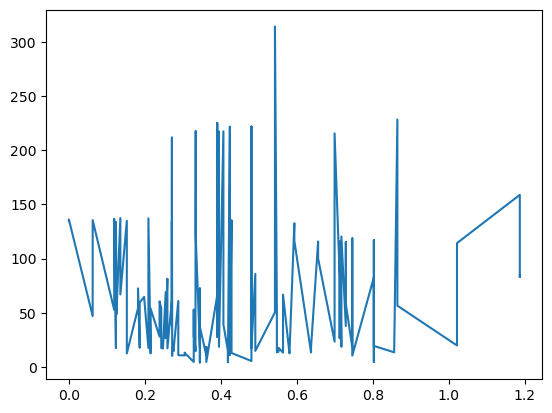

In [45]:
plt.plot(predictions_data_df["Utilization"], predictions_data_df["Actual App A Comm Time"])
plt.show()

Training Data Performance:

Training Data Evaluation Results
Mean Squared Error (MSE):        0.232937
Root Mean Squared Error (RMSE):  0.482636
Mean Absolute Error (MAE):       0.353228
R-squared (R²):                  0.767063
Explained Variance Score:        0.767559

Testing Data Performance:

Testing Data Evaluation Results
Mean Squared Error (MSE):        0.653161
Root Mean Squared Error (RMSE):  0.808184
Mean Absolute Error (MAE):       0.504754
R-squared (R²):                  0.554527
Explained Variance Score:        0.554798


Feature Importance Analysis

Feature Importances:
             Feature  Importance
   App B Total Bytes    0.324804
App A Total Messages    0.312450
     App B Comm Frac    0.195012
   App A Total Bytes    0.090187
App B Total Messages    0.039367
     App A Comm Frac    0.038181


/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two

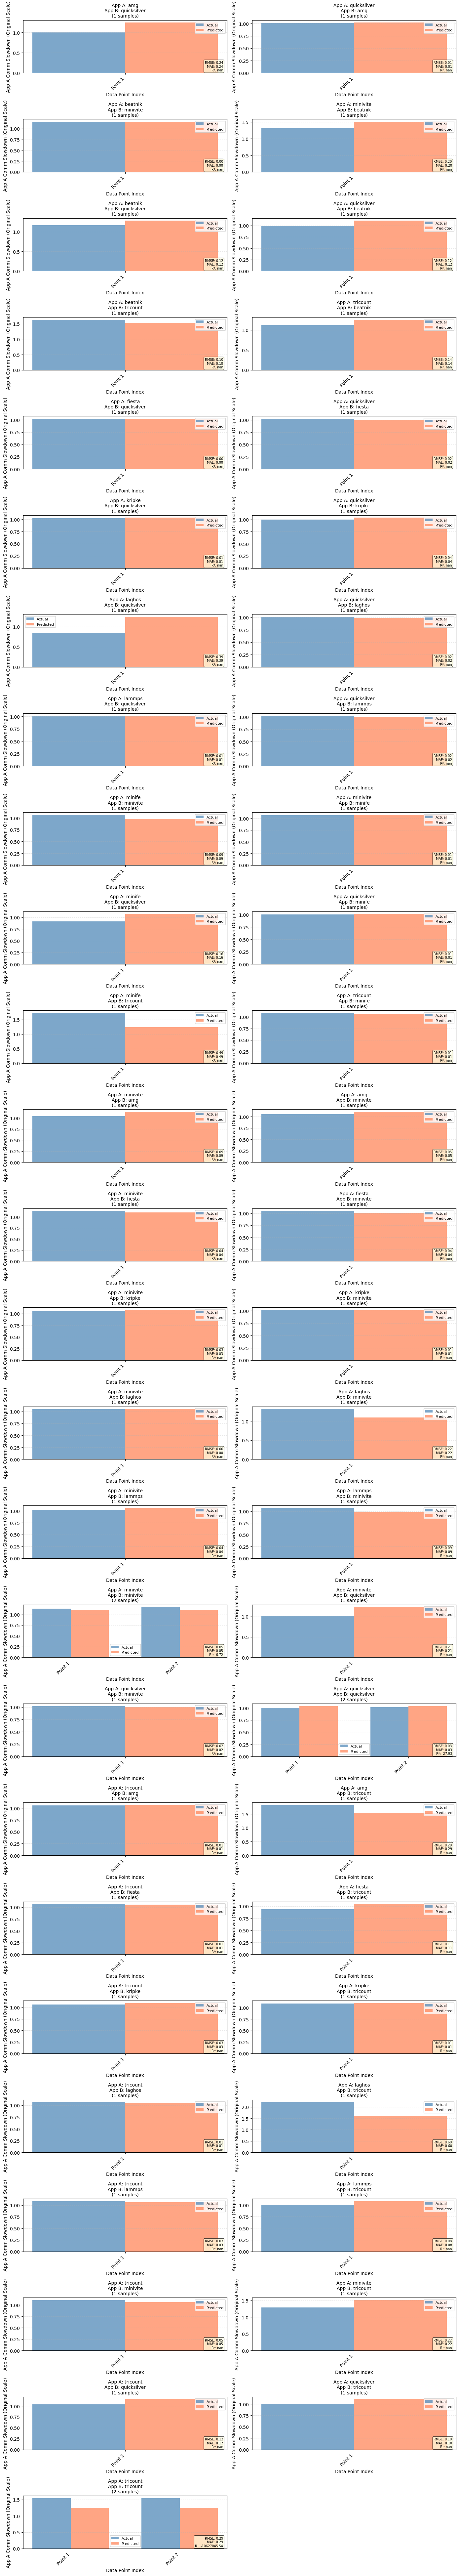

SUMMARY STATISTICS BY APP PAIRING

Pairing 1: App A: amg | App B: quicksilver
  Number of samples: 1
  RMSE: 0.2418 | MAE: 0.2418 | R²: nan
  Avg Actual: 1.0023 | Avg Predicted: 1.2441

Pairing 2: App A: quicksilver | App B: amg
  Number of samples: 1
  RMSE: 0.0089 | MAE: 0.0089 | R²: nan
  Avg Actual: 1.0111 | Avg Predicted: 1.0200

Pairing 3: App A: beatnik | App B: minivite
  Number of samples: 1
  RMSE: 0.0024 | MAE: 0.0024 | R²: nan
  Avg Actual: 1.1601 | Avg Predicted: 1.1577

Pairing 4: App A: minivite | App B: beatnik
  Number of samples: 1
  RMSE: 0.2019 | MAE: 0.2019 | R²: nan
  Avg Actual: 1.3103 | Avg Predicted: 1.5122

Pairing 5: App A: beatnik | App B: quicksilver
  Number of samples: 1
  RMSE: 0.1199 | MAE: 0.1199 | R²: nan
  Avg Actual: 1.1658 | Avg Predicted: 1.2857

Pairing 6: App A: quicksilver | App B: beatnik
  Number of samples: 1
  RMSE: 0.1177 | MAE: 0.1177 | R²: nan
  Avg Actual: 0.9903 | Avg Predicted: 1.1080

Pairing 7: App A: beatnik | App B: tricount
  Num

/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/akhil/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two

In [86]:
 # Back to ML, but use the profiling data

from sklearn.preprocessing import StandardScaler

# Generate training data
data_coscheduled_agg_filtered = data_coscheduled_agg[data_coscheduled_agg["Num Nodes"] == 8]
data_isolated_agg_filtered = data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]

training_apps = ["beatnik", "amg", "fiesta", "kripke", "laghos", "lammps", "minife"]

training_data = []
header = ["App A", "App B", "App A Comm Frac", "App B Comm Frac",
           "App A Total Messages", "App B Total Messages", "App A Total Bytes", "App B Total Bytes",
           "App A Comm Slowdown"]

for i in data_coscheduled_agg_filtered.iloc:
    if (i["App A"] in training_apps) and (i["App B"] in training_apps):
        app_a_iso = data_isolated_agg_filtered[data_isolated_agg_filtered["App"] == i["App A"]]
        app_b_iso = data_isolated_agg_filtered[data_isolated_agg_filtered["App"] == i["App B"]]
        training_data.append([i["App A"], i["App B"], app_a_iso["MPI Time Average Mean"].max()/app_a_iso["App Time Average Mean"].max(),
                              app_b_iso["MPI Time Average Mean"].max()/app_b_iso["App Time Average Mean"].max(),
                              app_a_iso["Total Messages Sent Mean"].max(), app_b_iso["Total Messages Sent Mean"].max(),
                              app_a_iso["Total Bytes Sent Mean"].max(), app_b_iso["Total Bytes Sent Mean"].max(),
                              i["App A MPI Time Average Mean"]/app_a_iso["MPI Time Average Mean"].max()])

        training_data.append([i["App B"], i["App A"], app_b_iso["MPI Time Average Mean"].max()/app_b_iso["App Time Average Mean"].max(),
                              app_a_iso["MPI Time Average Mean"].max()/app_a_iso["App Time Average Mean"].max(),
                              app_b_iso["Total Messages Sent Mean"].max(), app_a_iso["Total Messages Sent Mean"].max(),
                              app_b_iso["Total Bytes Sent Mean"].max(), app_a_iso["Total Bytes Sent Mean"].max(),
                              i["App B MPI Time Average Mean"]/app_b_iso["MPI Time Average Mean"].max()])
    else:
        continue

testing_data = []

for i in data_coscheduled_agg_filtered.iloc:
    if (i["App A"] not in training_apps) or (i["App B"] not in training_apps):
        app_a_iso = data_isolated_agg_filtered[data_isolated_agg_filtered["App"] == i["App A"]]
        app_b_iso = data_isolated_agg_filtered[data_isolated_agg_filtered["App"] == i["App B"]]
        testing_data.append([i["App A"], i["App B"], app_a_iso["MPI Time Average Mean"].max()/app_a_iso["App Time Average Mean"].max(),
                              app_b_iso["MPI Time Average Mean"].max()/app_b_iso["App Time Average Mean"].max(),
                              app_a_iso["Total Messages Sent Mean"].max(), app_b_iso["Total Messages Sent Mean"].max(),
                              app_a_iso["Total Bytes Sent Mean"].max(), app_b_iso["Total Bytes Sent Mean"].max(),
                              i["App A MPI Time Average Mean"]/app_a_iso["MPI Time Average Mean"].max()])

        testing_data.append([i["App B"], i["App A"], app_b_iso["MPI Time Average Mean"].max()/app_b_iso["App Time Average Mean"].max(),
                              app_a_iso["MPI Time Average Mean"].max()/app_a_iso["App Time Average Mean"].max(),
                              app_b_iso["Total Messages Sent Mean"].max(), app_a_iso["Total Messages Sent Mean"].max(),
                              app_b_iso["Total Bytes Sent Mean"].max(), app_a_iso["Total Bytes Sent Mean"].max(),
                              i["App B MPI Time Average Mean"]/app_b_iso["MPI Time Average Mean"].max()])
    else:
        continue

training_data_df = pd.DataFrame(training_data)
training_data_df.columns = header

testing_data_df = pd.DataFrame(testing_data)
testing_data_df.columns = header

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

# Define feature columns (only numeric, excludes 'App A', 'App B', and target)
numeric_cols = [
    'App A Comm Frac', 
    'App B Comm Frac', 
    'App A Total Messages', 
    'App B Total Messages', 
    'App A Total Bytes', 
    'App B Total Bytes'
]

# Split features (X) and target (y) from training and testing data
X_train_df = training_data_df.drop(['App A', 'App B', 'App A Comm Slowdown'], axis=1)
y_train = training_data_df['App A Comm Slowdown']

X_test_df = testing_data_df.drop(['App A', 'App B', 'App A Comm Slowdown'], axis=1)
y_test = testing_data_df['App A Comm Slowdown']

# Initialize and fit scalers on training data only
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaler.fit(X_train_df[numeric_cols])
y_scaler.fit(y_train.values.reshape(-1, 1))

# Scale features and target
X_train_scaled = X_scaler.transform(X_train_df[numeric_cols])
X_test_scaled = X_scaler.transform(X_test_df[numeric_cols])

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

# Train the Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(X_train_scaled, y_train_scaled)

# Predictions
y_train_pred = rf_regressor.predict(X_train_scaled)
y_test_pred = rf_regressor.predict(X_test_scaled)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{model_name} Evaluation Results")
    print(f"{'='*50}")
    print(f"Mean Squared Error (MSE):        {mse:.6f}")
    print(f"Root Mean Squared Error (RMSE):  {rmse:.6f}")
    print(f"Mean Absolute Error (MAE):       {mae:.6f}")
    print(f"R-squared (R²):                  {r2:.6f}")
    print(f"Explained Variance Score:        {evs:.6f}")
    print(f"{'='*50}\n")
    
    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'evs': evs
    }

# Evaluate model performance
print("Training Data Performance:")
train_metrics = evaluate_model(y_train_scaled, y_train_pred, "Training Data")

print("Testing Data Performance:")
test_metrics = evaluate_model(y_test_scaled, y_test_pred, "Testing Data")

# Feature Importance Analysis
print("\n" + "="*50)
print("Feature Importance Analysis")
print("="*50)
importances = rf_regressor.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance_df.to_string(index=False))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Inverse transform predictions and actual values
y_test_pred_original = y_scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()
y_test_original = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# Create dataframe with all relevant info
test_results_df = pd.DataFrame({
    'App A': testing_data_df['App A'],
    'App B': testing_data_df['App B'],
    'Actual': y_test_original,
    'Predicted': y_test_pred_original
})

# Count unique app pairings
unique_pairings = test_results_df[['App A', 'App B']].drop_duplicates().reset_index(drop=True)
n_pairings = len(unique_pairings)

# Determine subplot grid size (2 columns)
n_rows = int(np.ceil(n_pairings / 2))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3 * n_rows))

# If only one row, axes may not be 2D
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Plot for each unique app pairing
for idx, (_, row) in enumerate(unique_pairings.iterrows()):
    app_a, app_b = row['App A'], row['App B']
    pairing_data = test_results_df[(test_results_df['App A'] == app_a) & 
                                    (test_results_df['App B'] == app_b)]
    
    actual = pairing_data['Actual'].values
    predicted = pairing_data['Predicted'].values
    n_points = len(actual)
    
    # Get subplot axes
    row_idx = idx // 2
    col_idx = idx % 2
    ax = axes[row_idx, col_idx]
    
    # Create x-axis positions
    x = np.arange(n_points)
    width = 0.35
    
    # Create bar chart
    ax.bar(x - width/2, actual, width, label='Actual', color='steelblue', alpha=0.7)
    ax.bar(x + width/2, predicted, width, label='Predicted', color='coral', alpha=0.7)
    
    # Customize plot
    ax.set_xlabel('Data Point Index')
    ax.set_ylabel('App A Comm Slowdown (Original Scale)')
    ax.set_title(f'App A: {app_a}\nApp B: {app_b}\n({n_points} samples)', fontsize=10)
    ax.set_xticks(x)
    if n_points > 10:
        ax.set_xticklabels([f'{i+1}' for i in range(0, n_points, max(1, n_points//5))], rotation=45, ha='right')
    else:
        ax.set_xticklabels([f'Point {i+1}' for i in range(n_points)], rotation=45, ha='right')
    ax.legend(loc='best', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add RMSE annotation
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    ax.text(0.98, 0.02, f'RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.2f}', 
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Hide unused subplots
for idx in range(n_pairings, n_rows * 2):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

# Print summary statistics for each pairing
print("="*70)
print("SUMMARY STATISTICS BY APP PAIRING")
print("="*70)

for idx, (_, row) in enumerate(unique_pairings.iterrows()):
    app_a, app_b = row['App A'], row['App B']
    pairing_data = test_results_df[(test_results_df['App A'] == app_a) & 
                                    (test_results_df['App B'] == app_b)]
    
    actual = pairing_data['Actual'].values
    predicted = pairing_data['Predicted'].values
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    avg_actual = actual.mean()
    avg_predicted = predicted.mean()
    
    print(f"\nPairing {idx+1}: App A: {app_a} | App B: {app_b}")
    print(f"  Number of samples: {len(actual)}")
    print(f"  RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
    print(f"  Avg Actual: {avg_actual:.4f} | Avg Predicted: {avg_predicted:.4f}")

print("\n" + "="*70)
print(f"Total Testing Data Points: {len(test_results_df)}")
print(f"Unique App Pairings: {n_pairings}")
print("="*70)


In [85]:
testing_data_df

,App A,App B,App A Comm Frac,App B Comm Frac,App A Total Messages,App B Total Messages,App A Total Bytes,App B Total Bytes,App A Comm Slowdown
0,amg,quicksilver,0.037308,0.454222,106441449.0,762710.0,1.008232e+12,1.601104e+08,1.002297
1,quicksilver,amg,0.454222,0.037308,762710.0,106441449.0,1.601104e+08,1.008232e+12,1.011126
2,beatnik,minivite,0.251189,0.138983,19996182.0,24089720.0,1.092655e+13,1.134700e+12,1.160065
3,minivite,beatnik,0.138983,0.251189,24089720.0,19996182.0,1.134700e+12,1.092655e+13,1.310324
4,beatnik,quicksilver,0.251189,0.454222,19996182.0,762710.0,1.092655e+13,1.601104e+08,1.165774
5,quicksilver,beatnik,0.454222,0.251189,762710.0,19996182.0,1.601104e+08,1.092655e+13,0.990257
6,beatnik,tricount,0.251189,0.539874,19996182.0,7120960.0,1.092655e+13,1.020000e+13,1.631422
7,tricount,beatnik,0.539874,0.251189,7120960.0,19996182.0,1.020000e+13,1.092655e+13,1.119240
8,fiesta,quicksilver,0.182893,0.454222,645120.0,762710.0,1.640000e+12,1.601104e+08,1.018983
9,quicksilver,fiesta,0.454222,0.182893,762710.0,645120.0,1.601104e+08,1.640000e+12,1.025453
